**Install & Imports**

In [1]:
!pip -q install timm

import os, random
import numpy as np
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split

from torchvision import transforms
from torchvision.datasets import Food101

import timm

/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

**Config**

In [2]:
CFG = {
    "seed": 42,
    "model_name": "tf_efficientnet_b2",
    "img_size": 260,            # B2 works well around 260
    "batch_size": 32,          
    "num_workers": 2,

    # Two-stage training
    "epochs_head": 4,           # Stage A: train classifier head
    "epochs_finetune": 20,      # Stage B: fine-tune (partial unfreeze)
    "lr_head": 1e-3,
    "lr_finetune": 3e-5,        # smaller LR = better generalization

    "weight_decay": 1e-4,
    "label_smoothing": 0.1,

    # Early stopping
    "patience": 4,
    "min_delta": 1e-4,

    # MixUp helps reach >85% more reliably
    "use_mixup": True,
    "mixup_alpha": 0.2,
}

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True

set_seed(CFG["seed"])
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


**Transforms**

In [3]:
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

train_tfms = transforms.Compose([
    transforms.RandomResizedCrop(CFG["img_size"], scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_tfms = transforms.Compose([
    transforms.Resize(CFG["img_size"] + 32),
    transforms.CenterCrop(CFG["img_size"]),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

**Download and load dataset**

In [4]:
root = "/kaggle/working"

full_train_base = Food101(root=root, split="train", download=True)
test_ds = Food101(root=root, split="test", download=True)

print("Official train:", len(full_train_base))  # 75750
print("Official test :", len(test_ds))          # 25250
print("Classes       :", len(full_train_base.classes))  # 101

100%|██████████| 5.00G/5.00G [06:15<00:00, 13.3MB/s]   


Official train: 75750
Official test : 25250
Classes       : 101


**Split official train -> (68175 train, 7575 val)**

In [5]:
import torch
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, Subset
from torchvision.datasets import Food101

root = "/kaggle/working"
seed = 42

# Base dataset only for getting length / indices 
base_train = Food101(root=root, split="train", download=True)

# Create shuffled indices (reproducible)
g = torch.Generator().manual_seed(seed)
perm = torch.randperm(len(base_train), generator=g).tolist()

train_size = 68175
val_size = 7575

train_idx = perm[:train_size]
val_idx   = perm[train_size:train_size + val_size]

# Create TWO datasets with different transforms
train_base = Food101(root=root, split="train", transform=train_tfms, download=False)
val_base   = Food101(root=root, split="train", transform=val_tfms,   download=False)

# Subsets
train_ds = Subset(train_base, train_idx)
val_ds   = Subset(val_base,   val_idx)

# Official test set (untouched)
test_ds = Food101(root=root, split="test", transform=val_tfms, download=False)

print("Train:", len(train_ds), "Val:", len(val_ds), "Test:", len(test_ds))


train_loader = DataLoader(train_ds, batch_size=CFG["batch_size"], shuffle=True,
                          num_workers=CFG["num_workers"], pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=CFG["batch_size"]*2, shuffle=False,
                          num_workers=CFG["num_workers"], pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=CFG["batch_size"]*2, shuffle=False,
                          num_workers=CFG["num_workers"], pin_memory=True)


Train: 68175 Val: 7575 Test: 25250


In [6]:
x1, y1 = next(iter(train_loader))
x2, y2 = next(iter(train_loader))
print("Train batch difference (should be >0 with augmentation):", (x1 - x2).abs().mean().item())

xv1, yv1 = next(iter(val_loader))
xv2, yv2 = next(iter(val_loader))
print("Val batch difference (should be small ~0 because deterministic):", (xv1 - xv2).abs().mean().item())


Train batch difference (should be >0 with augmentation): 1.2867964506149292
Val batch difference (should be small ~0 because deterministic): 0.0


In [7]:
x, y = next(iter(train_loader))
print("Train batch:", x.shape, y.shape)
xv, yv = next(iter(val_loader))
print("Val batch:", xv.shape, yv.shape)


Train batch: torch.Size([32, 3, 260, 260]) torch.Size([32])
Val batch: torch.Size([64, 3, 260, 260]) torch.Size([64])


**Model + Loss**

In [8]:
num_classes = 101
model = timm.create_model(CFG["model_name"], pretrained=True, num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss(label_smoothing=CFG["label_smoothing"])

model.safetensors:   0%|          | 0.00/36.8M [00:00<?, ?B/s]

**Mixup helpers**

In [9]:
def mixup_data(x, y, alpha=0.2):
    if alpha <= 0:
        return x, y, None, 1.0
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0)).to(x.device)
    mixed_x = lam * x + (1 - lam) * x[idx]
    y_a, y_b = y, y[idx]
    return mixed_x, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

**Train/Eval**

In [10]:
def train_one_epoch(model, loader, optimizer):
    model.train()
    total_loss = 0.0

    for x, y in tqdm(loader, desc="Train", leave=False):
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad(set_to_none=True)

        if CFG["use_mixup"]:
            x_mix, y_a, y_b, lam = mixup_data(x, y, CFG["mixup_alpha"])
            logits = model(x_mix)
            loss = mixup_criterion(criterion, logits, y_a, y_b, lam)
        else:
            logits = model(x)
            loss = criterion(logits, y)

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item() * x.size(0)

    return total_loss / len(loader.dataset)

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    for x, y in tqdm(loader, desc="Eval", leave=False):
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item() * x.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += x.size(0)

    return total_loss / total, correct / total

def get_lr(optimizer):
    return optimizer.param_groups[0]["lr"]


**Two stage training with early stopping**

In [11]:
best_path = "/kaggle/working/best_food101_effnetb2.pth"
best_val_acc = 0.0

history = {
    "train_acc": [], "val_acc": [],
    "train_loss": [], "val_loss": [],
    "stage": []
}

patience = CFG["patience"]
min_delta = CFG["min_delta"]

# ---- Stage A: freeze backbone, train head
for p in model.parameters():
    p.requires_grad = False

for name, p in model.named_parameters():
    if ("classifier" in name) or ("head" in name) or ("fc" in name):
        p.requires_grad = True

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=CFG["lr_head"],
    weight_decay=CFG["weight_decay"]
)

# ReduceLROnPlateau without verbose (because Kaggle torch may not support verbose)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=1
)

patience_counter = 0

print("\n===== STAGE A: Train Head (Frozen Backbone) =====")
for epoch in range(CFG["epochs_head"]):
    print(f"\n[Stage A] Epoch {epoch+1}/{CFG['epochs_head']} | LR={get_lr(optimizer):.2e}")

    train_loss = train_one_epoch(model, train_loader, optimizer)

    # For reporting: compute true train accuracy on clean data (even if MixUp is ON)
    train_loss_eval, train_acc_eval = evaluate(model, train_loader)
    val_loss, val_acc = evaluate(model, val_loader)

    scheduler.step(val_loss)

    history["train_loss"].append(train_loss_eval)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc_eval)
    history["val_acc"].append(val_acc)
    history["stage"].append("A")

    print(f"Train Loss: {train_loss_eval:.4f} | Train Acc: {train_acc_eval*100:.2f}%")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc*100:.2f}%")

    # Early stopping on validation accuracy
    if val_acc > best_val_acc + min_delta:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_path)
        patience_counter = 0
        print("✅ Best model saved")
    else:
        patience_counter += 1
        print(f"⏳ No improvement. Patience: {patience_counter}/{patience}")
        if patience_counter >= patience:
            print("⏹️ Early stopping Stage A")
            break



===== STAGE A: Train Head (Frozen Backbone) =====

[Stage A] Epoch 1/4 | LR=1.00e-03


Train Loss: 2.4255 | Train Acc: 54.22%
Val   Loss: 2.3526 | Val   Acc: 57.16%
✅ Best model saved

[Stage A] Epoch 2/4 | LR=1.00e-03


Train Loss: 2.2483 | Train Acc: 59.31%
Val   Loss: 2.2120 | Val   Acc: 60.95%
✅ Best model saved

[Stage A] Epoch 3/4 | LR=1.00e-03


Train Loss: 2.1618 | Train Acc: 61.85%
Val   Loss: 2.2015 | Val   Acc: 61.32%
✅ Best model saved

[Stage A] Epoch 4/4 | LR=1.00e-03


Train Loss: 2.1211 | Train Acc: 63.04%
Val   Loss: 2.1967 | Val   Acc: 61.61%
✅ Best model saved


In [12]:
# ---- Stage B: load best, unfreeze last blocks + head, fine-tune with small LR
model.load_state_dict(torch.load(best_path, map_location=device))

# Freeze all
for p in model.parameters():
    p.requires_grad = False

# Unfreeze head
for name, p in model.named_parameters():
    if ("classifier" in name) or ("head" in name) or ("fc" in name):
        p.requires_grad = True

# Unfreeze last feature layers (timm often uses these names)
for name, p in model.named_parameters():
    if ("blocks" in name) or ("conv_head" in name) or ("bn2" in name):
        p.requires_grad = True

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=CFG["lr_finetune"],
    weight_decay=CFG["weight_decay"]
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=CFG["epochs_finetune"]
)

patience_counter = 0

print("\n===== STAGE B: Fine-tune (Partial Unfreeze) =====")
for epoch in range(CFG["epochs_finetune"]):
    print(f"\n[Stage B] Epoch {epoch+1}/{CFG['epochs_finetune']} | LR={get_lr(optimizer):.2e}")

    train_loss = train_one_epoch(model, train_loader, optimizer)

    train_loss_eval, train_acc_eval = evaluate(model, train_loader)
    val_loss, val_acc = evaluate(model, val_loader)

    scheduler.step()

    history["train_loss"].append(train_loss_eval)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc_eval)
    history["val_acc"].append(val_acc)
    history["stage"].append("B")

    print(f"Train Loss: {train_loss_eval:.4f} | Train Acc: {train_acc_eval*100:.2f}%")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc*100:.2f}%")

    if val_acc > best_val_acc + min_delta:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_path)
        patience_counter = 0
        print("✅ Best model saved")
    else:
        patience_counter += 1
        print(f"⏳ No improvement. Patience: {patience_counter}/{patience}")
        if patience_counter >= patience:
            print("⏹️ Early stopping Stage B")
            break

print("\nBest Val Acc:", best_val_acc * 100)
print("Saved best model to:", best_path)



===== STAGE B: Fine-tune (Partial Unfreeze) =====

[Stage B] Epoch 1/20 | LR=3.00e-05


Train Loss: 1.6452 | Train Acc: 77.97%
Val   Loss: 1.7535 | Val   Acc: 74.55%
✅ Best model saved

[Stage B] Epoch 2/20 | LR=2.98e-05


Train Loss: 1.5090 | Train Acc: 81.74%
Val   Loss: 1.6343 | Val   Acc: 77.41%
✅ Best model saved

[Stage B] Epoch 3/20 | LR=2.93e-05


Train Loss: 1.4606 | Train Acc: 83.94%
Val   Loss: 1.6215 | Val   Acc: 78.38%
✅ Best model saved

[Stage B] Epoch 4/20 | LR=2.84e-05


Train Loss: 1.3730 | Train Acc: 85.97%
Val   Loss: 1.5478 | Val   Acc: 79.54%
✅ Best model saved

[Stage B] Epoch 5/20 | LR=2.71e-05


...

Train Loss: 1.1049 | Train Acc: 94.38%
Val   Loss: 1.4581 | Val   Acc: 82.11%
✅ Best model saved

[Stage B] Epoch 16/20 | LR=4.39e-06


Train Loss: 1.1290 | Train Acc: 94.43%
Val   Loss: 1.4784 | Val   Acc: 82.09%
⏳ No improvement. Patience: 1/4

[Stage B] Epoch 17/20 | LR=2.86e-06


Train Loss: 1.1261 | Train Acc: 94.53%
Val   Loss: 1.4793 | Val   Acc: 82.02%
⏳ No improvement. Patience: 2/4

[Stage B] Epoch 18/20 | LR=1.63e-06


Train Loss: 1.1428 | Train Acc: 94.22%
Val   Loss: 1.4950 | Val   Acc: 81.85%
⏳ No improvement. Patience: 3/4

[Stage B] Epoch 19/20 | LR=7.34e-07


Train Loss: 1.1349 | Train Acc: 94.44%
Val   Loss: 1.4926 | Val   Acc: 81.74%
⏳ No improvement. Patience: 4/4
⏹️ Early stopping Stage B

Best Val Acc: 82.11221122112211
Saved best model to: /kaggle/working/best_food101_effnetb2.pth


**Load the trained model**

In [13]:
import torch
import timm
from torchvision import transforms
from PIL import Image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = timm.create_model(
    "tf_efficientnet_b2",
    pretrained=False,
    num_classes=101
).to(device)

model.load_state_dict(
    torch.load("/kaggle/working/best_food101_effnetb2.pth", map_location=device)
)

model.eval()
print("Model loaded and ready")


Model loaded and ready


**Define the SAME preprocessing used in validation**

In [14]:
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

infer_transform = transforms.Compose([
    transforms.Resize(260 + 32),
    transforms.CenterCrop(260),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


**Load class names (Food-101 labels)**

In [15]:
from torchvision.datasets import Food101

dummy_ds = Food101(root="/kaggle/working", split="train", download=False)
class_names = dummy_ds.classes  # list of 101 food names

print(class_names[:10])  # sanity check


['apple_pie', 'baby_back_ribs', 'baklava', 'beef_carpaccio', 'beef_tartare', 'beet_salad', 'beignets', 'bibimbap', 'bread_pudding', 'breakfast_burrito']


**Load an input image,
Image from Food-101 dataset**

In [16]:
img_path = "/kaggle/working/food-101/images/pizza/1001116.jpg"


**Run inference on the image**

In [17]:
# Load image
img = Image.open(img_path).convert("RGB")

# Preprocess
x = infer_transform(img).unsqueeze(0).to(device)  # shape: [1, 3, H, W]

# Predict
with torch.no_grad():
    logits = model(x)
    probs = torch.softmax(logits, dim=1)
    conf, pred_idx = probs.max(dim=1)

pred_class = class_names[pred_idx.item()]
confidence = conf.item() * 100

print(f"Predicted class: {pred_class}")
print(f"Confidence: {confidence:.2f}%")


Predicted class: pizza
Confidence: 79.70%


In [18]:
from torch.utils.data import DataLoader
from tqdm import tqdm

# Test transforms (same as validation)
test_tfms = val_tfms

# Attach transforms to test dataset
test_ds.transform = test_tfms

test_loader = DataLoader(
    test_ds,
    batch_size=CFG["batch_size"],
    shuffle=False,
    num_workers=CFG["num_workers"],
    pin_memory=True
)

def evaluate_accuracy(model, loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in tqdm(loader, desc="Test"):
            x, y = x.to(device), y.to(device)
            logits = model(x)
            preds = torch.argmax(logits, dim=1)

            correct += (preds == y).sum().item()
            total += y.size(0)

    return correct / total


test_acc = evaluate_accuracy(model, test_loader)
print(f"✅ Test Accuracy: {test_acc:.4f}")


Test: 100%|██████████| 790/790 [01:21<00:00,  9.74it/s]

✅ Test Accuracy: 0.8697


**Add metrics function**

In [19]:
import torch
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

def evaluate_classification(model, loader, device):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            labels = labels.to(device)

            outputs = model(imgs)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return np.array(all_preds), np.array(all_labels)

**test evaluation**

In [20]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# load best model
ckpt = torch.load("/kaggle/working/best_food101_effnetb2.pth", map_location=device)

model.load_state_dict(ckpt)

model.eval()

# collect predictions
y_pred = []
y_true = []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        outputs = model(imgs)
        preds = torch.argmax(outputs, dim=1)

        y_pred.extend(preds.cpu().numpy())
        y_true.extend(labels.cpu().numpy())

import numpy as np
y_pred = np.array(y_pred)
y_true = np.array(y_true)

# metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average="macro")
recall = recall_score(y_true, y_pred, average="macro")
f1 = f1_score(y_true, y_pred, average="macro")

print("===== FINAL TEST RESULTS =====")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

===== FINAL TEST RESULTS =====
Accuracy  : 0.8697
Precision : 0.8699
Recall    : 0.8697
F1 Score  : 0.8693


**classification report**

In [21]:
from sklearn.metrics import classification_report

print("===== CLASSIFICATION REPORT =====")
print(classification_report(y_true, y_pred))

===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

           0       0.79      0.68      0.73       250
           1       0.89      0.85      0.87       250
           2       0.92      0.91      0.91       250
           3       0.94      0.89      0.91       250
           4       0.84      0.86      0.85       250
           5       0.79      0.77      0.78       250
           6       0.88      0.92      0.90       250
           7       0.93      0.94      0.93       250
           8       0.73      0.73      0.73       250
           9       0.86      0.84      0.85       250
          10       0.84      0.82      0.83       250
          11       0.84      0.93      0.88       250
          12       0.92      0.97      0.95       250
          13       0.88      0.90      0.89       250
          14       0.82      0.84      0.83       250
          15       0.83      0.76      0.79       250
          16       0.90      0.87      0.89    

**confusion matrix**

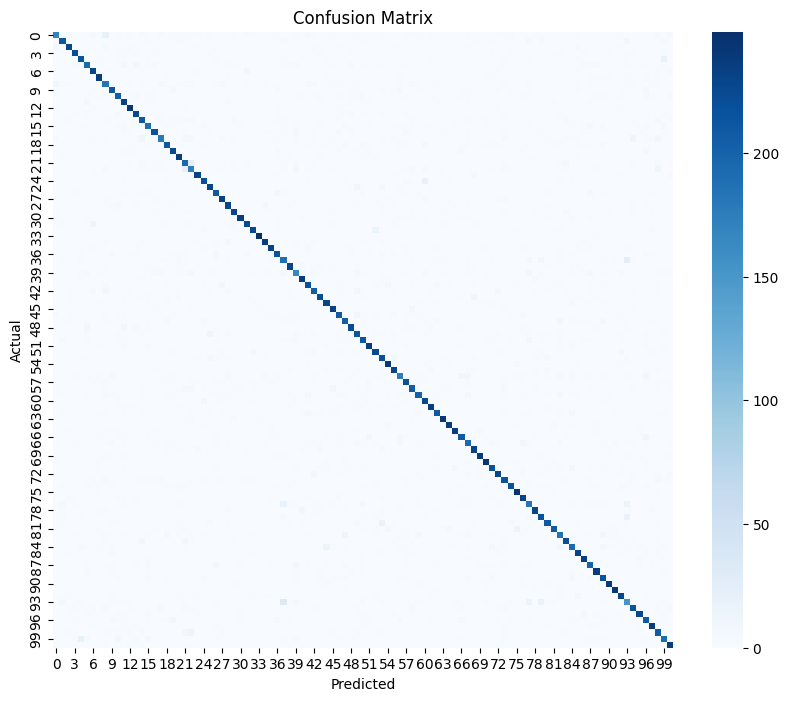

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**Create food101_idx_to_class.json**

In [23]:
import json

# If train_ds is a Subset, the real ImageFolder is inside train_ds.dataset
base_ds = train_ds.dataset  # this is usually ImageFolder

# Sometimes base_ds can itself be another Subset (rare), unwrap again
while hasattr(base_ds, "dataset"):
    base_ds = base_ds.dataset

# Now base_ds should be ImageFolder and has class_to_idx
idx_to_class = {v: k for k, v in base_ds.class_to_idx.items()}

with open("/kaggle/working/food101_idx_to_class.json", "w") as f:
    json.dump(idx_to_class, f, indent=2)

print("✅ Saved: /kaggle/working/food101_idx_to_class.json")
print("Example mappings:", list(idx_to_class.items())[:5])
print("Index range:", min(idx_to_class.keys()), "to", max(idx_to_class.keys()))


✅ Saved: /kaggle/working/food101_idx_to_class.json
Example mappings: [(0, 'apple_pie'), (1, 'baby_back_ribs'), (2, 'baklava'), (3, 'beef_carpaccio'), (4, 'beef_tartare')]
Index range: 0 to 100


**Single Image Prediction (Unseen Data)**

In [36]:
import torch
from PIL import Image
import matplotlib.pyplot as plt

def predict_single_image(image_path):
    model.eval()

    # Load image
    image = Image.open(image_path).convert("RGB")

    # Apply validation transform
    input_tensor = val_tfms(image).unsqueeze(0).to(device)

    # Prediction
    with torch.no_grad():
        outputs = model(input_tensor)
        probs = torch.softmax(outputs, dim=1)

    # Top-1 prediction
    conf, pred = torch.max(probs, dim=1)
    pred_class = class_names[pred.item()]
    confidence = conf.item()

    # Top-5 predictions
    top5_prob, top5_idx = torch.topk(probs, 5)
    top5_classes = [class_names[i] for i in top5_idx[0].cpu().numpy()]
    top5_scores = top5_prob[0].cpu().numpy()

    # Show image
    plt.figure(figsize=(5, 5))
    plt.imshow(image)
    plt.title(f"Pred: {pred_class} ({confidence:.3f})")
    plt.axis("off")
    plt.show()

    print("Top-1 Prediction:")
    print(f"{pred_class} ({confidence:.3f})\n")

    print("Top-5 Predictions:")
    for c, s in zip(top5_classes, top5_scores):
        print(f"{c:25s} {s:.3f}")

    return pred_class, confidence

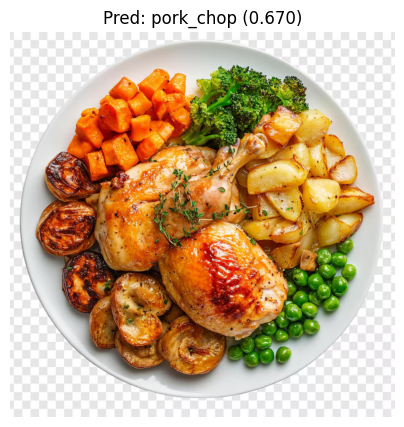

Top-1 Prediction:
pork_chop (0.670)

Top-5 Predictions:
pork_chop                 0.670
grilled_salmon            0.184
scallops                  0.045
filet_mignon              0.010
gnocchi                   0.008


('pork_chop', 0.6700588464736938)

In [41]:
test_image = "/kaggle/input/datasets/rkr2001/unseen-data/dinner-plate.png"
predict_single_image(test_image)

**Test with Multiple Unseen Images**


Testing: /kaggle/input/datasets/rkr2001/unseen-data/cake.jpg


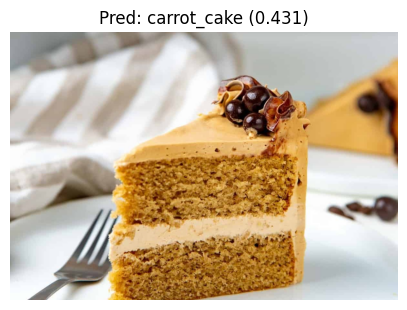

Top-1 Prediction:
carrot_cake (0.431)

Top-5 Predictions:
carrot_cake               0.431
cheesecake                0.074
chocolate_cake            0.070
tiramisu                  0.041
red_velvet_cake           0.031

Testing: /kaggle/input/datasets/rkr2001/unseen-data/Hamburger.jpg


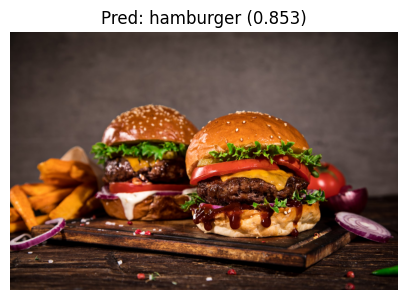

Top-1 Prediction:
hamburger (0.853)

Top-5 Predictions:
hamburger                 0.853
escargots                 0.007
pulled_pork_sandwich      0.006
caprese_salad             0.006
club_sandwich             0.005

Testing: /kaggle/input/datasets/rkr2001/unseen-data/pizza.jpg


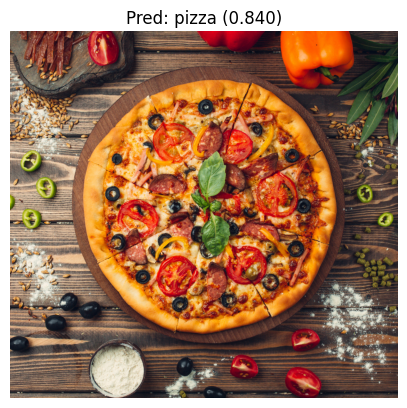

Top-1 Prediction:
pizza (0.840)

Top-5 Predictions:
pizza                     0.840
paella                    0.009
caprese_salad             0.007
nachos                    0.006
garlic_bread              0.005

Testing: /kaggle/input/datasets/rkr2001/unseen-data/ice cream.jpg


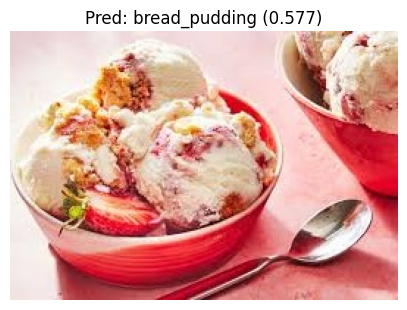

Top-1 Prediction:
bread_pudding (0.577)

Top-5 Predictions:
bread_pudding             0.577
ice_cream                 0.174
strawberry_shortcake      0.058
beignets                  0.015
french_toast              0.015


In [43]:
test_images = [
    "/kaggle/input/datasets/rkr2001/unseen-data/cake.jpg",
    "/kaggle/input/datasets/rkr2001/unseen-data/Hamburger.jpg",
    "/kaggle/input/datasets/rkr2001/unseen-data/pizza.jpg",
    "/kaggle/input/datasets/rkr2001/unseen-data/ice cream.jpg"
]

for img_path in test_images:
    print("\n==============================")
    print("Testing:", img_path)

    try:
        predict_single_image(img_path)   # ✅ ONLY THIS
    except Exception as e:
        print("Error:", e)